<a href="https://www.kaggle.com/code/sonawanelalitsunil/coffee-shop-revenue-prediction-ml-94-92?scriptVersionId=224549598" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv


## Title:
## "Coffee Shop Revenue Prediction Dataset"

## Dataset Description:
The Coffee Shop Revenue Prediction Dataset is designed for data analysis and machine learning tasks to forecast daily revenue based on various influencing factors. This dataset contains transactional, operational, and external factors that impact a coffee shop's daily sales.

## Columns & Features:

Date – The specific date of the revenue record.

Day of the Week – The day corresponding to the date (e.g., Monday, Tuesday).

Daily Revenue (INR/USD/etc.) – The total revenue generated on a given day.

Total Customers – The count of customers who visited the shop.

Average Order Value (AOV) – The average amount spent per order.

Number of Transactions – The total number of transactions processed in a day.

Weather Condition – The weather on that day (Sunny, Rainy, Cloudy, etc.).

Temperature (°C/°F) – The recorded temperature for that day.

Promotional Discounts (%) – The percentage of discount applied to items that day.

Special Events/Offers – Indicator for special promotions, holidays, or events.

Competitor Proximity (km/miles) – Distance to the nearest competing coffee shop.

Customer Loyalty Score – A score reflecting customer retention and loyalty.

Peak Hours Sales (%) – Percentage of revenue generated during peak hours.

Online Orders – The number of orders placed through online delivery platforms.

Staff Count – The number of employees working on that day.

## Use Cases:

Revenue Forecasting: Predict daily sales based on weather, discounts, and customer traffic.

Demand Analysis: Understand how different factors influence customer visits.

Marketing Effectiveness: Evaluate the impact of promotions and discounts.

Operational Optimization: Determine optimal staffing and inventory needs.

Competitor Impact Assessment: Measure how nearby competition affects sales trends.

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Import Dataset

In [3]:
df = pd.read_csv('/kaggle/input/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv')

In [4]:
df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42


In [5]:
df.tail()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
1995,372,6.41,11,4,466.11,913,2816.85
1996,105,3.01,11,7,12.62,235,337.97
1997,89,5.28,16,9,376.64,310,951.34
1998,403,9.41,7,12,452.49,577,4266.21
1999,89,6.88,13,14,78.46,322,914.24


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [7]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


In [8]:
df.dtypes

Number_of_Customers_Per_Day      int64
Average_Order_Value            float64
Operating_Hours_Per_Day          int64
Number_of_Employees              int64
Marketing_Spend_Per_Day        float64
Location_Foot_Traffic            int64
Daily_Revenue                  float64
dtype: object

In [9]:
df.shape

(2000, 7)

In [10]:
df.isnull().sum()

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64

In [11]:
df.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

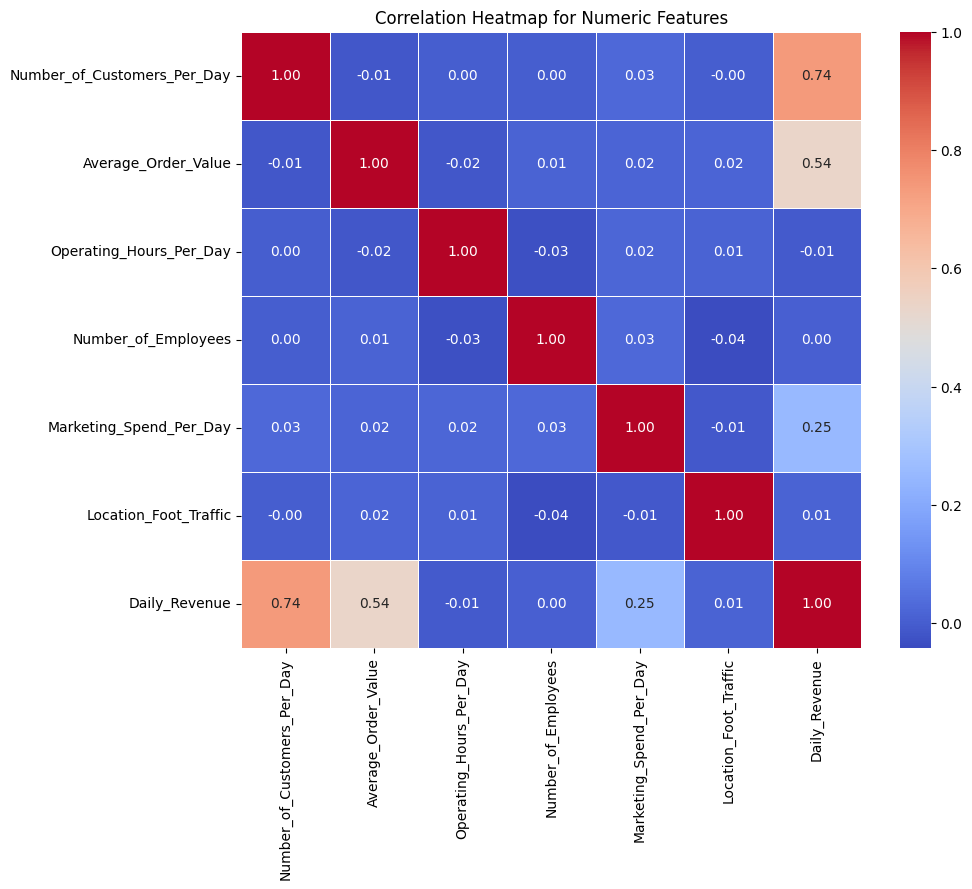

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Heatmap for Numeric Features')
    plt.show()
else:
    print('Not enough numeric columns to display a correlation heatmap.')

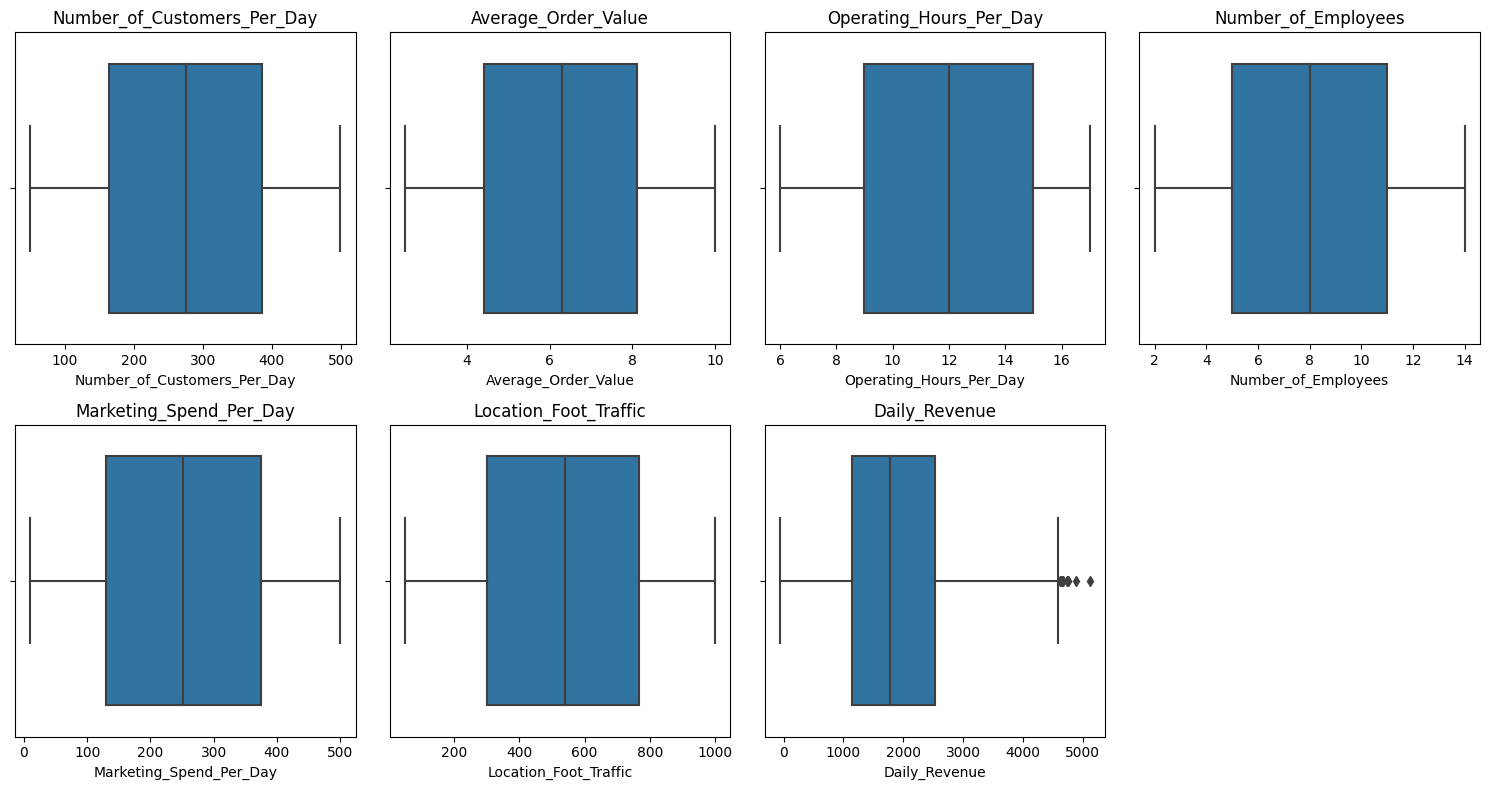

In [13]:
numeric_cols = numeric_df.columns
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

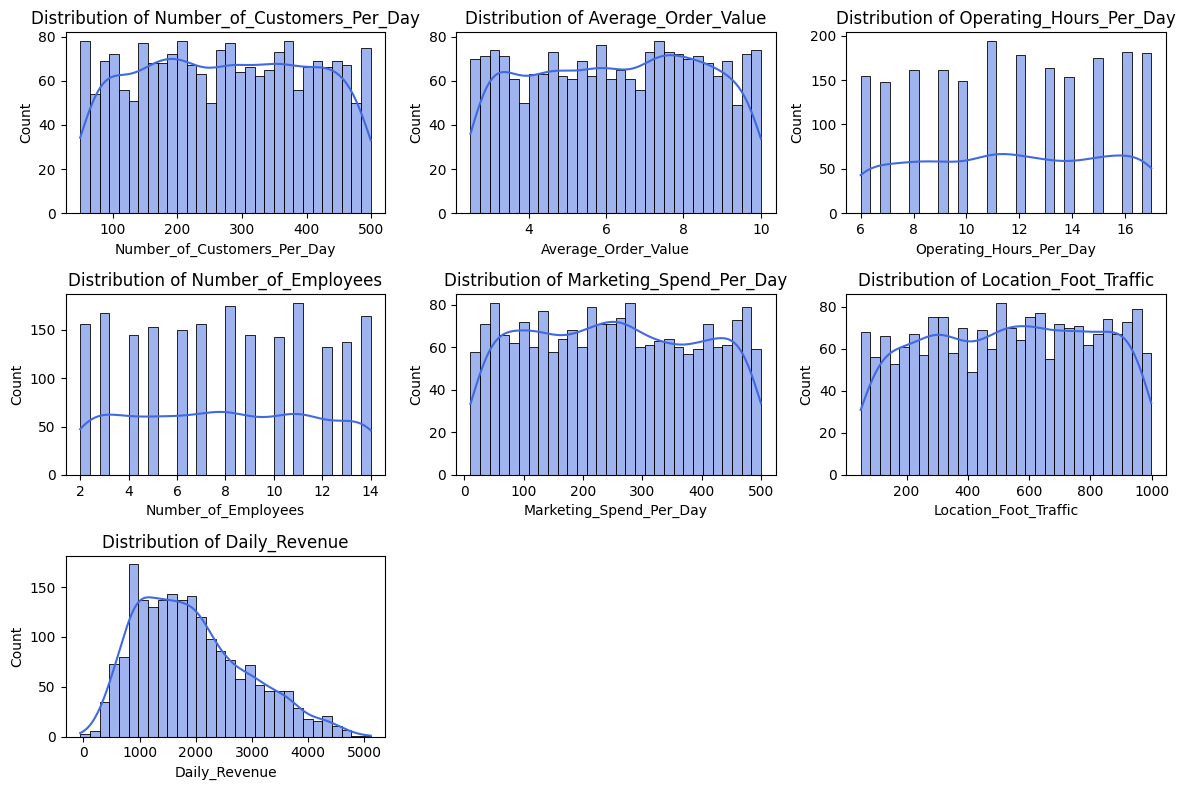

In [14]:
numeric_cols = ['Number_of_Customers_Per_Day', 'Average_Order_Value', 
                'Operating_Hours_Per_Day', 'Number_of_Employees', 
                'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue']

# Plot histograms
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], bins=30, kde=True, color='royalblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

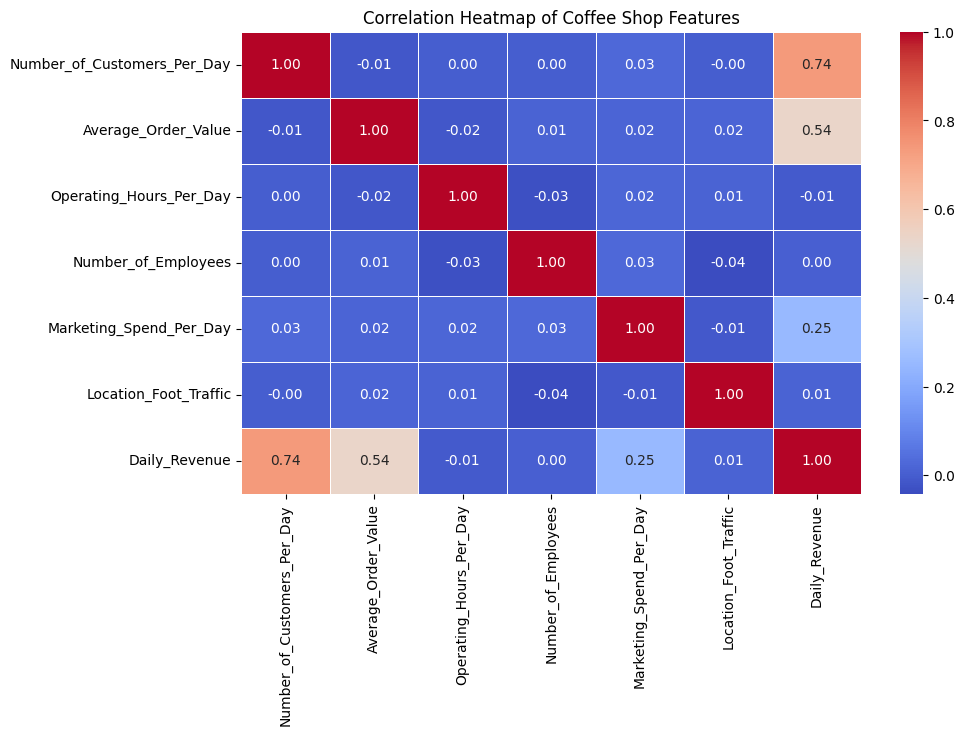

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Coffee Shop Features')
plt.show()

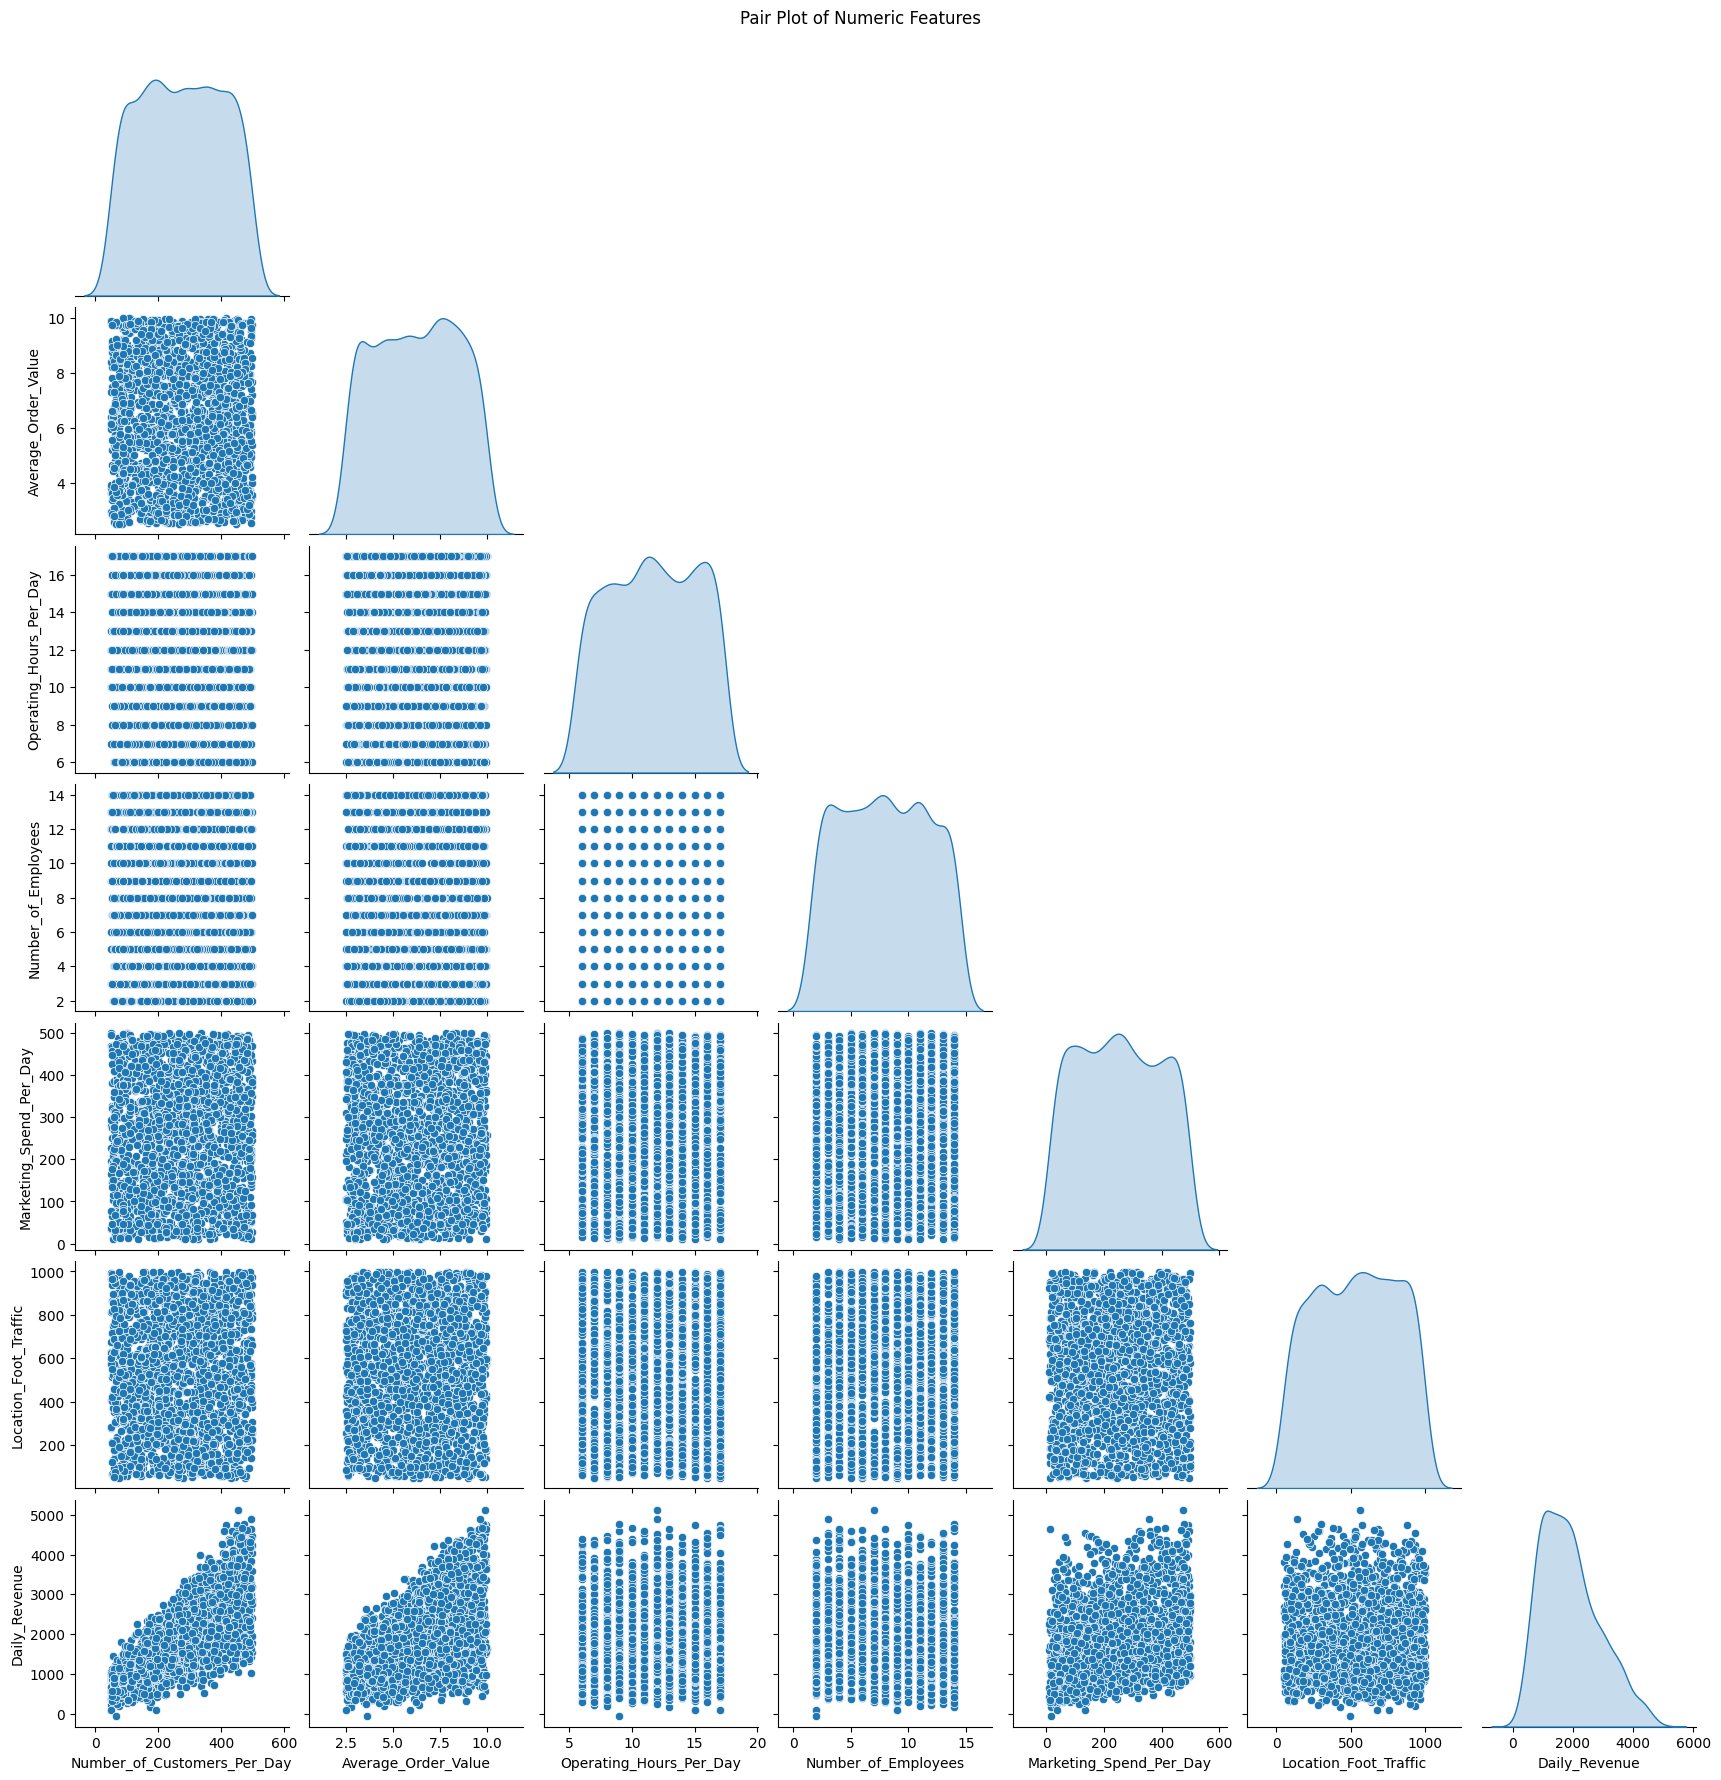

In [16]:
sns.pairplot(df, diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

In [17]:
df['Date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='D')

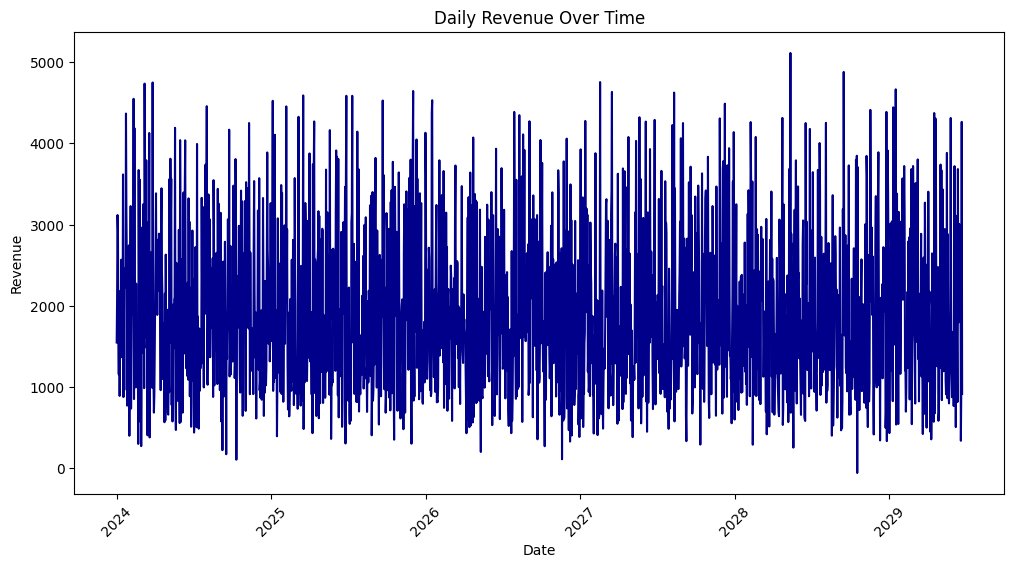

In [18]:
df['Date'] = pd.to_datetime(df['Date'])  # Ensure Date format
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Daily_Revenue', color='darkblue')
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

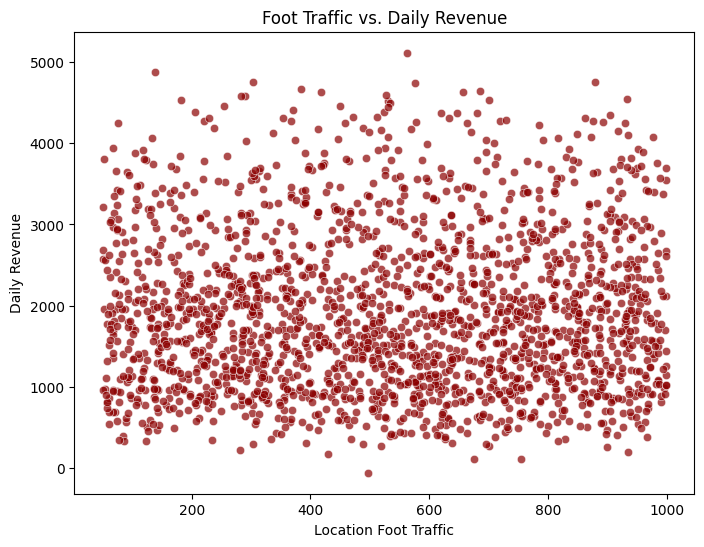

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Location_Foot_Traffic', y='Daily_Revenue', color='darkred', alpha=0.7)
plt.title('Foot Traffic vs. Daily Revenue')
plt.xlabel('Location Foot Traffic')
plt.ylabel('Daily Revenue')
plt.show()

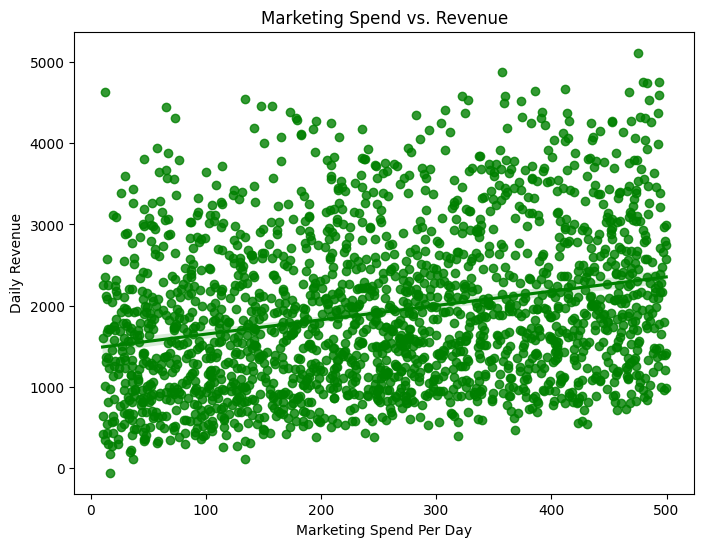

In [20]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Marketing_Spend_Per_Day', y='Daily_Revenue', color='green')
plt.title('Marketing Spend vs. Revenue')
plt.xlabel('Marketing Spend Per Day')
plt.ylabel('Daily Revenue')
plt.show()

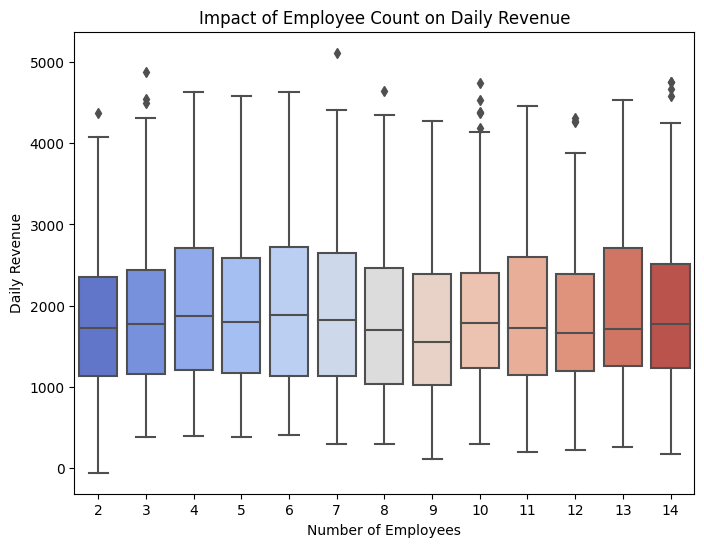

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Number_of_Employees', y='Daily_Revenue', palette='coolwarm')
plt.title('Impact of Employee Count on Daily Revenue')
plt.xlabel('Number of Employees')
plt.ylabel('Daily Revenue')
plt.show()

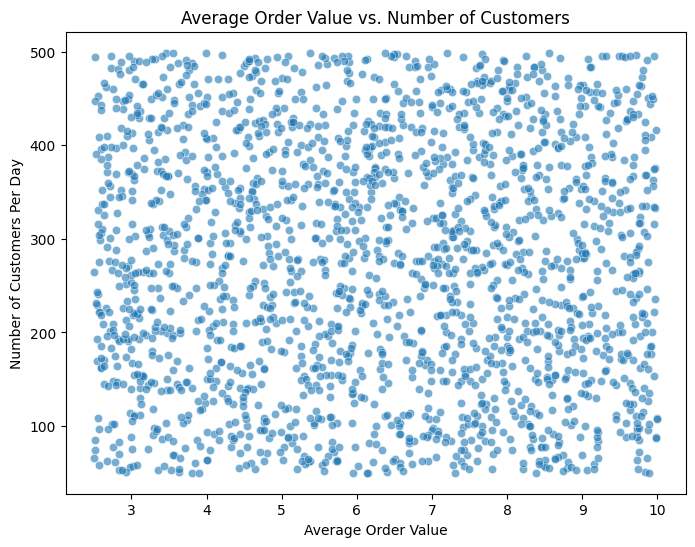

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Average_Order_Value', y='Number_of_Customers_Per_Day', alpha=0.6)
plt.title('Average Order Value vs. Number of Customers')
plt.xlabel('Average Order Value')
plt.ylabel('Number of Customers Per Day')
plt.show()

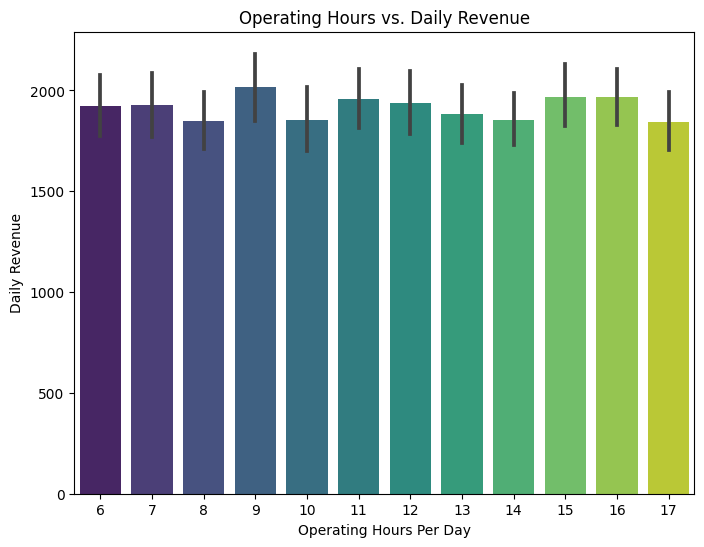

In [23]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Operating_Hours_Per_Day', y='Daily_Revenue', palette='viridis')
plt.title('Operating Hours vs. Daily Revenue')
plt.xlabel('Operating Hours Per Day')
plt.ylabel('Daily Revenue')
plt.show()

## Machine learning algorithms

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load your dataset
# df = pd.read_csv("your_dataset.csv")  

# Define Features and Target Variable
target = 'Daily_Revenue'
features = ['Number_of_Customers_Per_Day', 'Average_Order_Value',
            'Operating_Hours_Per_Day', 'Number_of_Employees',
            'Marketing_Spend_Per_Day', 'Location_Foot_Traffic']

# Split Data
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ML Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# Store Model Results
results = {}

# Train and Evaluate Each Model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred) * 100  # Convert to percentage
    results[name] = {'RMSE': rmse, 'R² Score (%)': r2}

    print(f"{name}:\n RMSE: {rmse:.2f}, R² Score: {r2:.2f}%\n")

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)


Linear Regression:
 RMSE: 312.36, R² Score: 89.56%

Decision Tree:
 RMSE: 329.94, R² Score: 88.35%

Random Forest:
 RMSE: 217.95, R² Score: 94.92%

Gradient Boosting:
 RMSE: 218.12, R² Score: 94.91%

XGBoost:
 RMSE: 233.23, R² Score: 94.18%

                         RMSE  R² Score (%)
Linear Regression  312.361526     89.557684
Decision Tree      329.943326     88.349074
Random Forest      217.948512     94.916187
Gradient Boosting  218.119322     94.908215
XGBoost            233.227036     94.178438


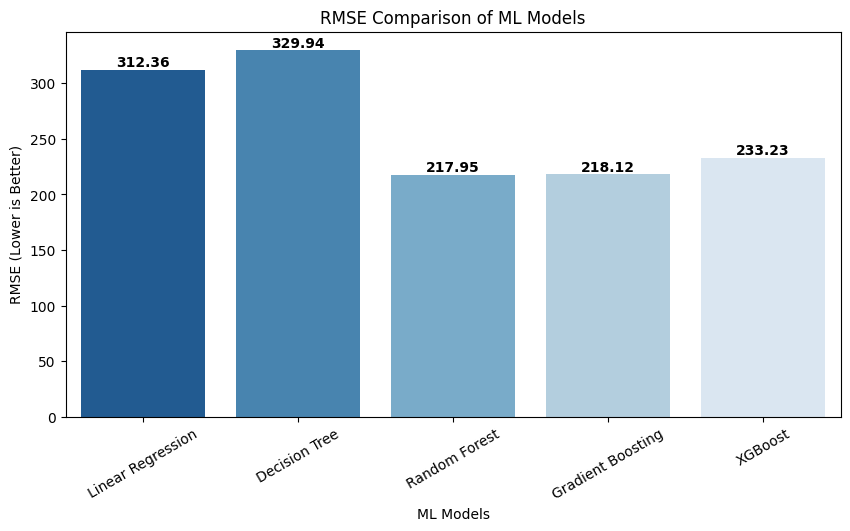

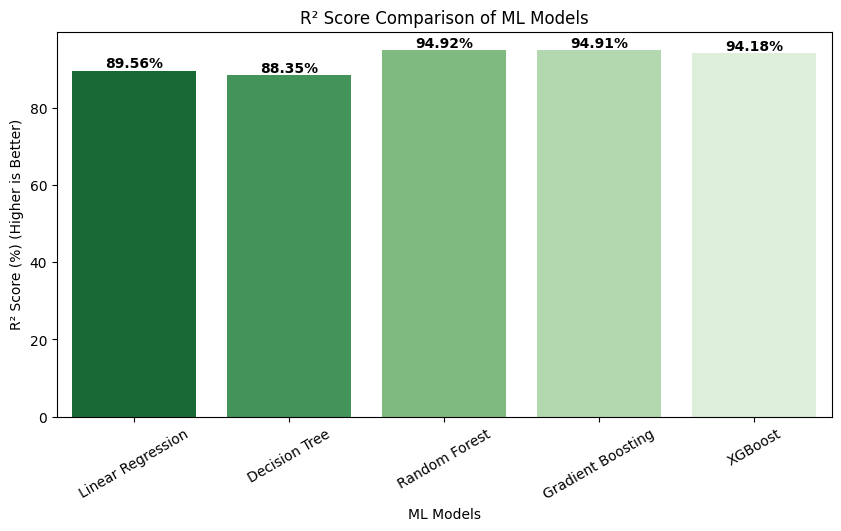

In [25]:
results = {
    "Linear Regression": {"RMSE": 312.36, "R² Score (%)": 89.56},
    "Decision Tree": {"RMSE": 329.94, "R² Score (%)": 88.35},
    "Random Forest": {"RMSE": 217.95, "R² Score (%)": 94.92},
    "Gradient Boosting": {"RMSE": 218.12, "R² Score (%)": 94.91},
    "XGBoost": {"RMSE": 233.23, "R² Score (%)": 94.18}
}

# Convert to DataFrame
results_df = pd.DataFrame(results).T

# RMSE Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=results_df.index, y=results_df["RMSE"], palette="Blues_r")
plt.xlabel("ML Models")
plt.ylabel("RMSE (Lower is Better)")
plt.title("RMSE Comparison of ML Models")
plt.xticks(rotation=30)

# Add percentage text on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.show()

# R² Score Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=results_df.index, y=results_df["R² Score (%)"], palette="Greens_r")
plt.xlabel("ML Models")
plt.ylabel("R² Score (%) (Higher is Better)")
plt.title("R² Score Comparison of ML Models")
plt.xticks(rotation=30)

# Add percentage text on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

plt.show()


## Thank you...pls upvote...